In [1]:
#used libs
import numpy as np
import pandas as pd
import sklearn
import sklearn.preprocessing, sklearn.cluster, sklearn.metrics
import scipy.spatial
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Data loading from 'CHY0092/student-mat.csv'
df = pd.read_csv('CHY0092/student-mat.csv')
df.head()
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

## Sloupce a jejich předpokládaný význam
* school = GP/MS presumed shortcuts for names
* sex = F/M
* age - 15, 16, 17, 18, 19, 20, 21, 22
* address - U - Urban, R - Rural
* famsize - GT3 means >= 3 a LE3 means <= 3
* Pstatus - T (together) or P (apart), Parent Status
* Medu - mothers edu, higher num => higher edu
* Fedu
* Mjob - mothers job, diff strings also at_home option
* Fjob
* reason - reasons for studying, course - attractive courses, home - close to home
* guardian - mother/father/other
* traveltime - actual brackets of mins already translated to nums, higher num => higher time
* studytime - higher num => more time assumed, already converted
* failures - num of failed classes
* schoolsup - extra study support from school, y/n
* famsup - extra support from family, y/n
* paid - extra paid tutoring, y/n
* activities - extra curicular activiteis, y/n
* nursery - y/n, student went to preschool
* higher - y/n, wants to persue higher edu
* internet - has access to internet
* romantic - has a partner
* famrel - relationship with family, higher num => better relationship, already in ordinal categorization
* freetime - already OG
* goout - freq of going out with friends, 1-5, higher better
* Dalc - OG, 1-4, workday alcohol consumption, higher num => more alchohol
* Walc - OG, same as above except for weekend
* health - OG, 1-5, higher num is better
* absences - absent from school 0 to 75
* G1 - students performance in first third of course, 3 - 19, higher num => higher score
* G2 - second third
* G3

## Kontrola dat

In [3]:
#rows, cols
df.shape

(395, 33)

In [4]:
#Types
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

In [5]:
#Null vals
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [6]:
#Duplicates check
print(df.duplicated().sum())

0


## EDA - explorative data analysis
* distribuce pohlaví
* distribuce urban/rural
* distribuce absencí
* distribuce škol
* vliv alkoholu na známky
* demografická korelace (sex, age, traveltime, address, health) a známek
* korelace společenského života (famrel, goout, activities, romantic) a známek
* korelace rodinného zázemí (Fedu, Medu, Fjob, Mjob, Pstatus, famsup, famrel) a známek


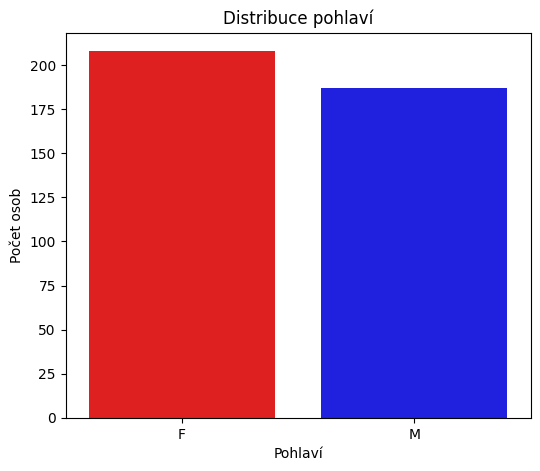

In [7]:
plt.figure(figsize=(6, 5)) 

sns.countplot(
    x=df['sex'],
    data=df,
    hue=df['sex'],
    palette={'M': 'blue', 'F': 'red'},
    legend=False
)

plt.title('Distribuce pohlaví')
plt.xlabel('Pohlaví')
plt.ylabel('Počet osob')

plt.show()

In [8]:
counts = df['sex'].value_counts()

Fcnt = counts.get('F', 0)
Mcnt = counts.get('M', 0)

res = Fcnt - Mcnt

print(f"Ve vzorku je o {res} více žen.")

Ve vzorku je o 21 více žen.


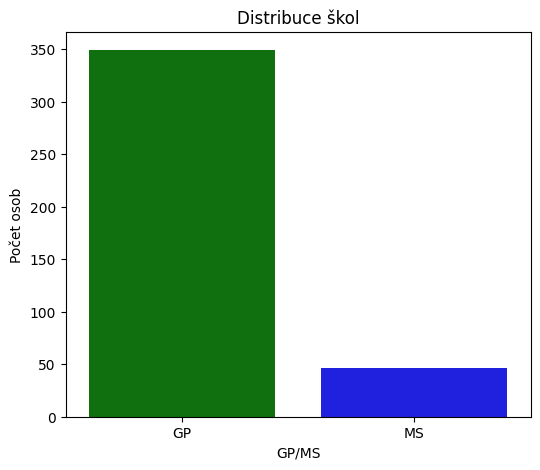

In [9]:
plt.figure(figsize=(6, 5)) 

sns.countplot(
    x='school',
    data=df,
    hue='school',
    palette={'MS': 'blue', 'GP': 'green'},
    legend=False
)

plt.title('Distribuce škol')
plt.xlabel('GP/MS')
plt.ylabel('Počet osob')

plt.show()

In [10]:
counts = df['school'].value_counts()

GPcnt = counts.get('GP', 0)
MScnt = counts.get('MS', 0)

res = GPcnt - MScnt

print(f"Ve vzorku je o {res} více studentů z GP.")

Ve vzorku je o 303 více studentů z GP.


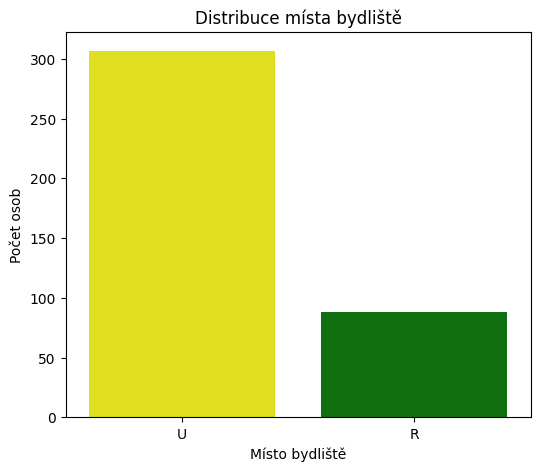

In [11]:
plt.figure(figsize=(6, 5)) 

sns.countplot(
    x=df['address'],
    data=df,
    hue=df['address'],
    palette={'U': 'yellow', 'R': 'green'},
    legend=False
)

plt.title('Distribuce místa bydliště')
plt.xlabel('Místo bydliště')
plt.ylabel('Počet osob')

plt.show()

In [12]:
counts = df['address'].value_counts()

Ucnt = counts.get('U', 0)
Rcnt = counts.get('R', 0)

res = Ucnt - Rcnt

print(f"Ve vzorku je o {res} více urbanistů.")

Ve vzorku je o 219 více urbanistů.


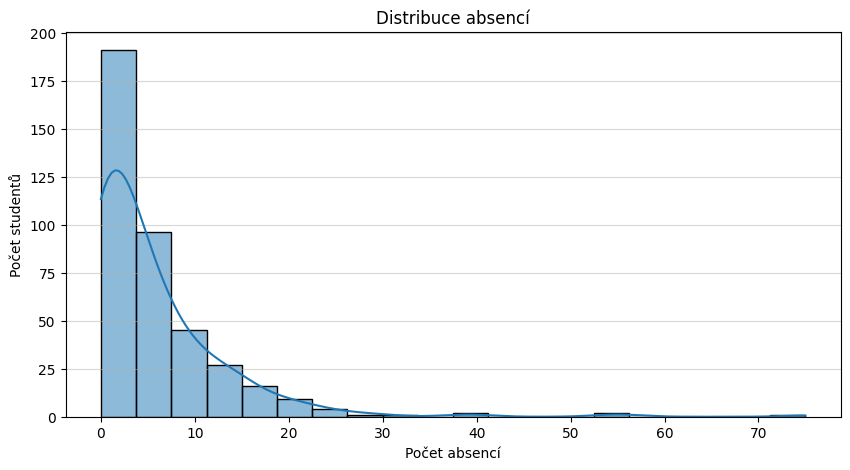

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x=df['absences'],
    bins=20,
    kde=True #adds a smooth curve to show the overall shape
)

plt.title('Distribuce absencí')
plt.xlabel('Počet absencí')
plt.ylabel('Počet studentů')
plt.grid(axis='y', alpha=0.5)

plt.show()

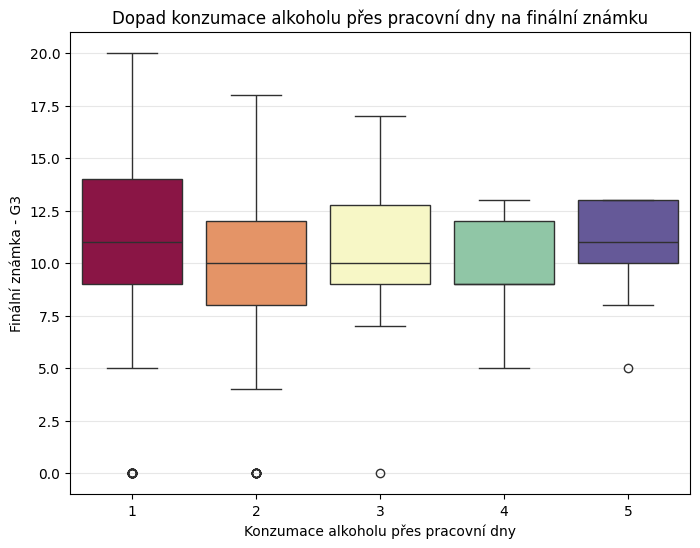

In [14]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='Dalc',           
    y='G3',             
    data=df,
    hue = 'Dalc',
    palette='Spectral',
    legend=False
)

plt.title('Dopad konzumace alkoholu přes pracovní dny na finální známku')
plt.xlabel('Konzumace alkoholu přes pracovní dny')
plt.ylabel('Finální známka - G3')
plt.grid(axis='y', alpha=0.3)

plt.show()

## Závěr
* Těžcí alkoholici dosahují zhruba stejného medianu jako ti co pijí nejméně.
* Bohužel nelze poměřit s abstinenty. Ti se patrně nepočítají.

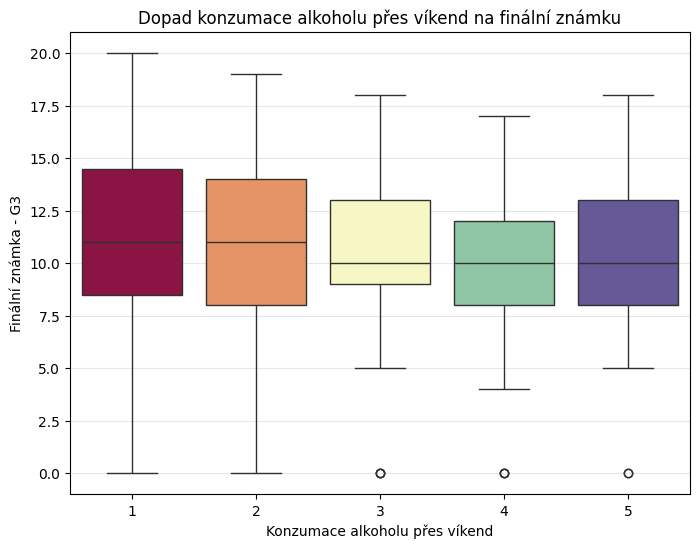

In [15]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='Walc',           
    y='G3',             
    data=df,
    hue = 'Walc',
    palette='Spectral',
    legend=False
)

plt.title('Dopad konzumace alkoholu přes víkend na finální známku')
plt.xlabel('Konzumace alkoholu přes víkend')
plt.ylabel('Finální známka - G3')
plt.grid(axis='y', alpha=0.3)

plt.show()

## Závěr
* Požívání alkoholu přes víkend se jeví jako o něco méně rozhodující kritérium hlavně u 1. a 2. skupiny.
* Distribuce medianů pro Walc je více stabilní distribuce mediánů pro Dalc.

In [16]:
#preprocessing for correlations
df = pd.read_csv('CHY0092/student-mat.csv')
df_enc = df
df_enc

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


### Demografická korelace (school, sex, age, traveltime, address, health, Fedu, Medu, nursery) a známek (G1, G2, G3)

In [17]:
#sex encoding
m = {'F': 1, 'M': 0}
df_enc['sex'] = df_enc['sex'].map(m)

In [18]:
#school encoding
m = {'GP': 1, 'MS' : 0}
df_enc['school'] = df_enc['school'].map(m)

In [19]:
#address encoding
m = {'U': 1, 'R' : 0}
df_enc['address'] = df_enc['address'].map(m)

In [20]:
#preschool encoding
m = {'yes': 1, 'no': 0}
df_enc['nursery'] = df_enc['nursery'].map(m)

In [21]:
#age, traveltine and heath are already encoded
#check of relevant vals
dem_cols = ['school', 'sex', 'age', 'traveltime', 'address', 'health', 'Fedu', 'Medu', 'nursery']
df_enc[dem_cols]

,school,sex,age,traveltime,address,health,Fedu,Medu,nursery
0,1,1,18,2,1,3,4,4,1
1,1,1,17,1,1,3,1,1,0
2,1,1,15,1,1,3,1,1,1
3,1,1,15,1,1,5,2,4,1
4,1,1,16,1,1,5,3,3,1
...,...,...,...,...,...,...,...,...,...
390,0,0,20,1,1,4,2,2,1
391,0,0,17,2,1,2,1,3,0
392,0,0,21,1,0,3,1,1,0
393,0,0,18,3,0,5,2,3,0


In [22]:
#and grades
g_cols = ['G1', 'G2', 'G3']
df_enc[g_cols]

,G1,G2,G3
0,5,6,6
1,5,5,6
2,7,8,10
3,15,14,15
4,6,10,10
...,...,...,...
390,9,9,9
391,14,16,16
392,10,8,7
393,11,12,10


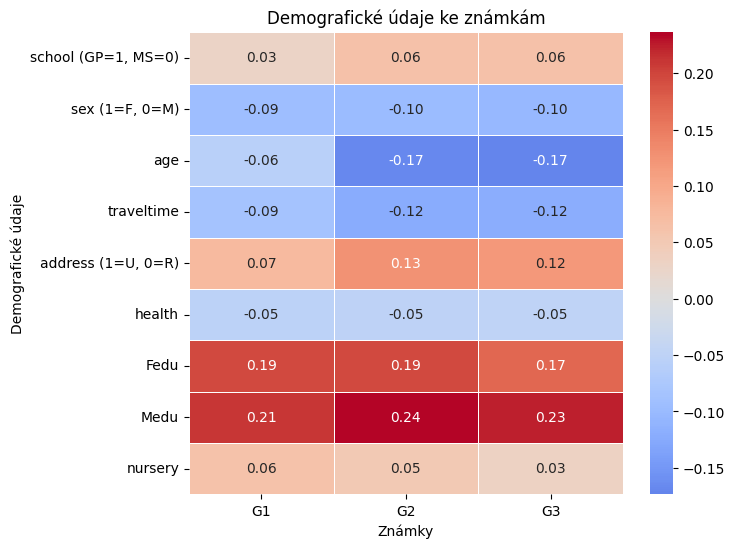

In [23]:
#cols to calc corr matrix on
all_cols = dem_cols + g_cols
#calcs correlation matrix
corr_matrix = df_enc[all_cols].corr(method='spearman')
#plot filter, shrinks the res by dropping all rows other then for dem_cols and drops all colls not for g_cols
corr_subset = corr_matrix.loc[dem_cols, g_cols]
#rename indices for display
corr_subset.rename(index={
    'sex': 'sex (1=F, 0=M)',
    'address': 'address (1=U, 0=R)',
    'school' : 'school (GP=1, MS=0)',
    
}, inplace=True)

#graph plotting
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_subset,
    annot=True, #incl r-value in graph
    fmt=".2f", #format r-value
    cmap='coolwarm', #color scale: cool=positive, warm=negative
    center=0, #center the color scale to 0 => white = 0
    linewidths=.5, #adds space between cells
)
plt.title('Demografické údaje ke známkám')
plt.ylabel('Demografické údaje')
plt.xlabel('Známky')
plt.show()

Demografické údaje patrně příliš nekorelují se známkami. 

### Korelace společenského života (famrel, goout, activities, romantic, nursery) a známek

In [24]:
#Encoding activities
m = {'yes': 1, 'no': 0}
df_enc['activities'] = df_enc['activities'].map(m)

In [25]:
#Encoding romantic
m = {'yes': 1, 'no': 0}
df_enc['romantic'] = df_enc['romantic'].map(m)

In [26]:
#famrel, goout already encoded out of the box, nursery encoded for previous mat
#check of rel cols
soc_cols = ['famrel', 'goout', 'activities', 'romantic', 'nursery']
df_enc[soc_cols]

,famrel,goout,activities,romantic,nursery
0,4,4,0,0,1
1,5,3,0,0,0
2,4,2,0,0,1
3,3,2,1,1,1
4,4,2,0,0,1
...,...,...,...,...,...
390,5,4,0,0,1
391,2,5,0,0,0
392,5,3,0,0,0
393,4,1,0,0,0


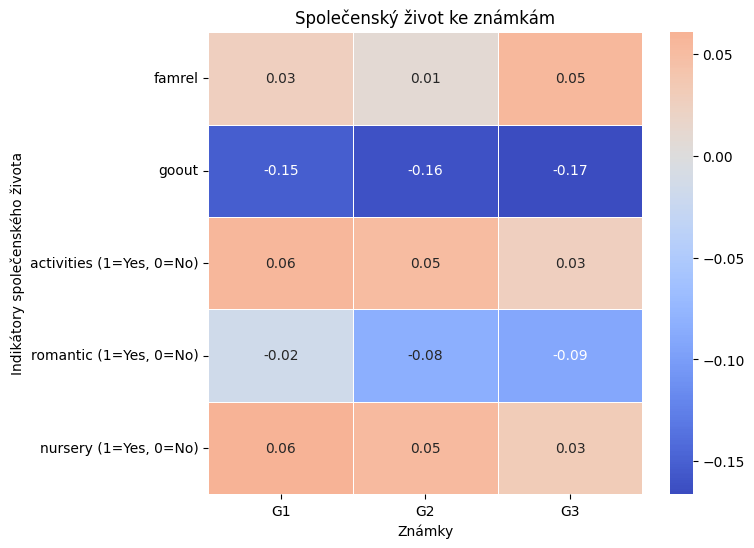

In [27]:
#cols to calc corr matrix on
all_cols = soc_cols + g_cols
#calcs correlation matrix
corr_matrix = df_enc[all_cols].corr(method='spearman')
#plot filter, shrinks the res by dropping all rows other then for soc_cols and drops all colls not for g_cols
corr_subset = corr_matrix.loc[soc_cols, g_cols]
#rename indices for display
corr_subset.rename(index={
    'activities': 'activities (1=Yes, 0=No)',
    'romantic': 'romantic (1=Yes, 0=No)',
    'nursery' : 'nursery (1=Yes, 0=No)',
    
}, inplace=True)

#graph plotting
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_subset,
    annot=True, #incl r-value in graph
    fmt=".2f", #format r-value
    cmap='coolwarm', #color scale: cool=positive, warm=negative
    center=0, #center the color scale to 0 => white = 0
    linewidths=.5, #adds space between cells
)
plt.title('Společenský život ke známkám')
plt.ylabel('Indikátory společenského života')
plt.xlabel('Známky')
plt.show()

Překvapivě ani zde nejsou žádné silné korelace.

### Korelace rodinného zázemí (Fedu, Medu, Pstatus, famsup, famrel, famsize) a známek

In [28]:
df_enc['Pstatus'].unique()

array(['A', 'T'], dtype=object)

In [29]:
#Encoding Pstatus
m = {'A': 0, 'T': 1}
df_enc['Pstatus'] = df_enc['Pstatus'].map(m)

In [30]:
#Encoding famsup
m = {'no': 0, 'yes': 1}
df_enc['famsup'] = df_enc['famsup'].map(m)

In [31]:
#Encoding famsize
m = {'GT3': 1, 'LE3': 0}
df_enc['famsize'] = df_enc['famsize'].map(m)

In [32]:
#Fjob, Mjob unable to meaningfully encode, unused
#Fedu, Medu, famrel already encoded out of the box
fam_cols = ['Fedu', 'Medu', 'Pstatus', 'famsup', 'famrel', 'famsize']
df_enc[fam_cols]


,Fedu,Medu,Pstatus,famsup,famrel,famsize
0,4,4,0,0,4,1
1,1,1,1,1,5,1
2,1,1,1,0,4,0
3,2,4,1,1,3,1
4,3,3,1,1,4,1
...,...,...,...,...,...,...
390,2,2,0,1,5,0
391,1,3,1,0,2,0
392,1,1,1,0,5,1
393,2,3,1,0,4,0


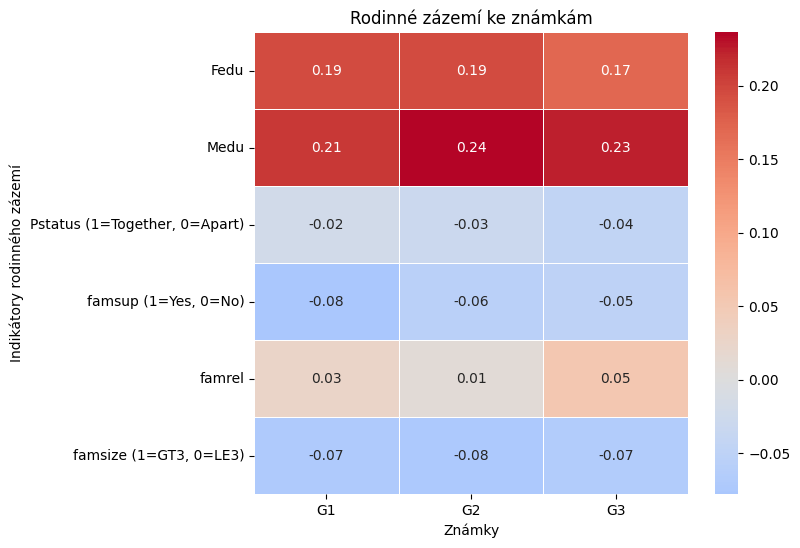

In [33]:
#cols to calc corr matrix on
all_cols = fam_cols + g_cols
#calcs correlation matrix
corr_matrix = df_enc[all_cols].corr(method='spearman')
#plot filter, shrinks the res by dropping all rows other then for soc_cols and drops all colls not for g_cols
corr_subset = corr_matrix.loc[fam_cols, g_cols]
#rename indices for display
corr_subset.rename(index={
    'Pstatus': 'Pstatus (1=Together, 0=Apart)',
    'famsup': 'famsup (1=Yes, 0=No)',
    'famsize' : 'famsize (1=GT3, 0=LE3)',
    
}, inplace=True)

#graph plotting
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_subset,
    annot=True, #incl r-value in graph
    fmt=".2f", #format r-value
    cmap='coolwarm', #color scale: cool=positive, warm=negative
    center=0, #center the color scale to 0 => white = 0
    linewidths=.5, #adds space between cells
)
plt.title('Rodinné zázemí ke známkám')
plt.ylabel('Indikátory rodinného zázemí')
plt.xlabel('Známky')
plt.show()

### Závěr: 
* Opět žádné lineární korelace, snad kromě vzdělaní rodičů, primárně matky.

## Příprava pro clustering 

In [34]:
#data prep
df_enc.dtypes

school         int64
sex            int64
age            int64
address        int64
famsize        int64
Pstatus        int64
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup         int64
paid          object
activities     int64
nursery        int64
higher        object
internet      object
romantic       int64
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

### Příprava korelační matice pro odstranění sloupců

In [35]:
#encoding remaining values
#Mjob and Fjob will be ignored

In [36]:
#encoding reason via OHE
reason_dummies = pd.get_dummies(
    df_enc['reason'], 
    prefix='reason',
)
#merge back into df_enc
df_enc = pd.concat([df_enc, reason_dummies], axis=1)

#drop original reason
df_enc = df_enc.drop('reason', axis=1)

In [37]:
#encoding gurdian also as OHE
#encoding reason via OHE
reason_dummies = pd.get_dummies(
    df_enc['guardian'], 
    prefix='guardian',
)
#merge back into df_enc
df_enc = pd.concat([df_enc, reason_dummies], axis=1)

#drop original guardian
df_enc = df_enc.drop('guardian', axis=1)

In [38]:
#encoding paid (tutoring) as 1/0
m = {'no': 0, 'yes': 1}
df_enc['paid'] = df_enc['paid'].map(m)

In [39]:
#encoding schoolsup
m = {'no': 0, 'yes': 1}
df_enc['schoolsup'] = df_enc['schoolsup'].map(m)

In [40]:
#encoding higher
m = {'no': 0, 'yes': 1}
df_enc['higher'] = df_enc['higher'].map(m)

In [41]:
#encoding internet
m = {'no': 0, 'yes': 1}
df_enc['internet'] = df_enc['internet'].map(m)

In [42]:
#dropping jobs, edu will have to do, already too many cols
df_enc = df_enc.drop('Fjob', axis=1)
df_enc = df_enc.drop('Mjob', axis=1)

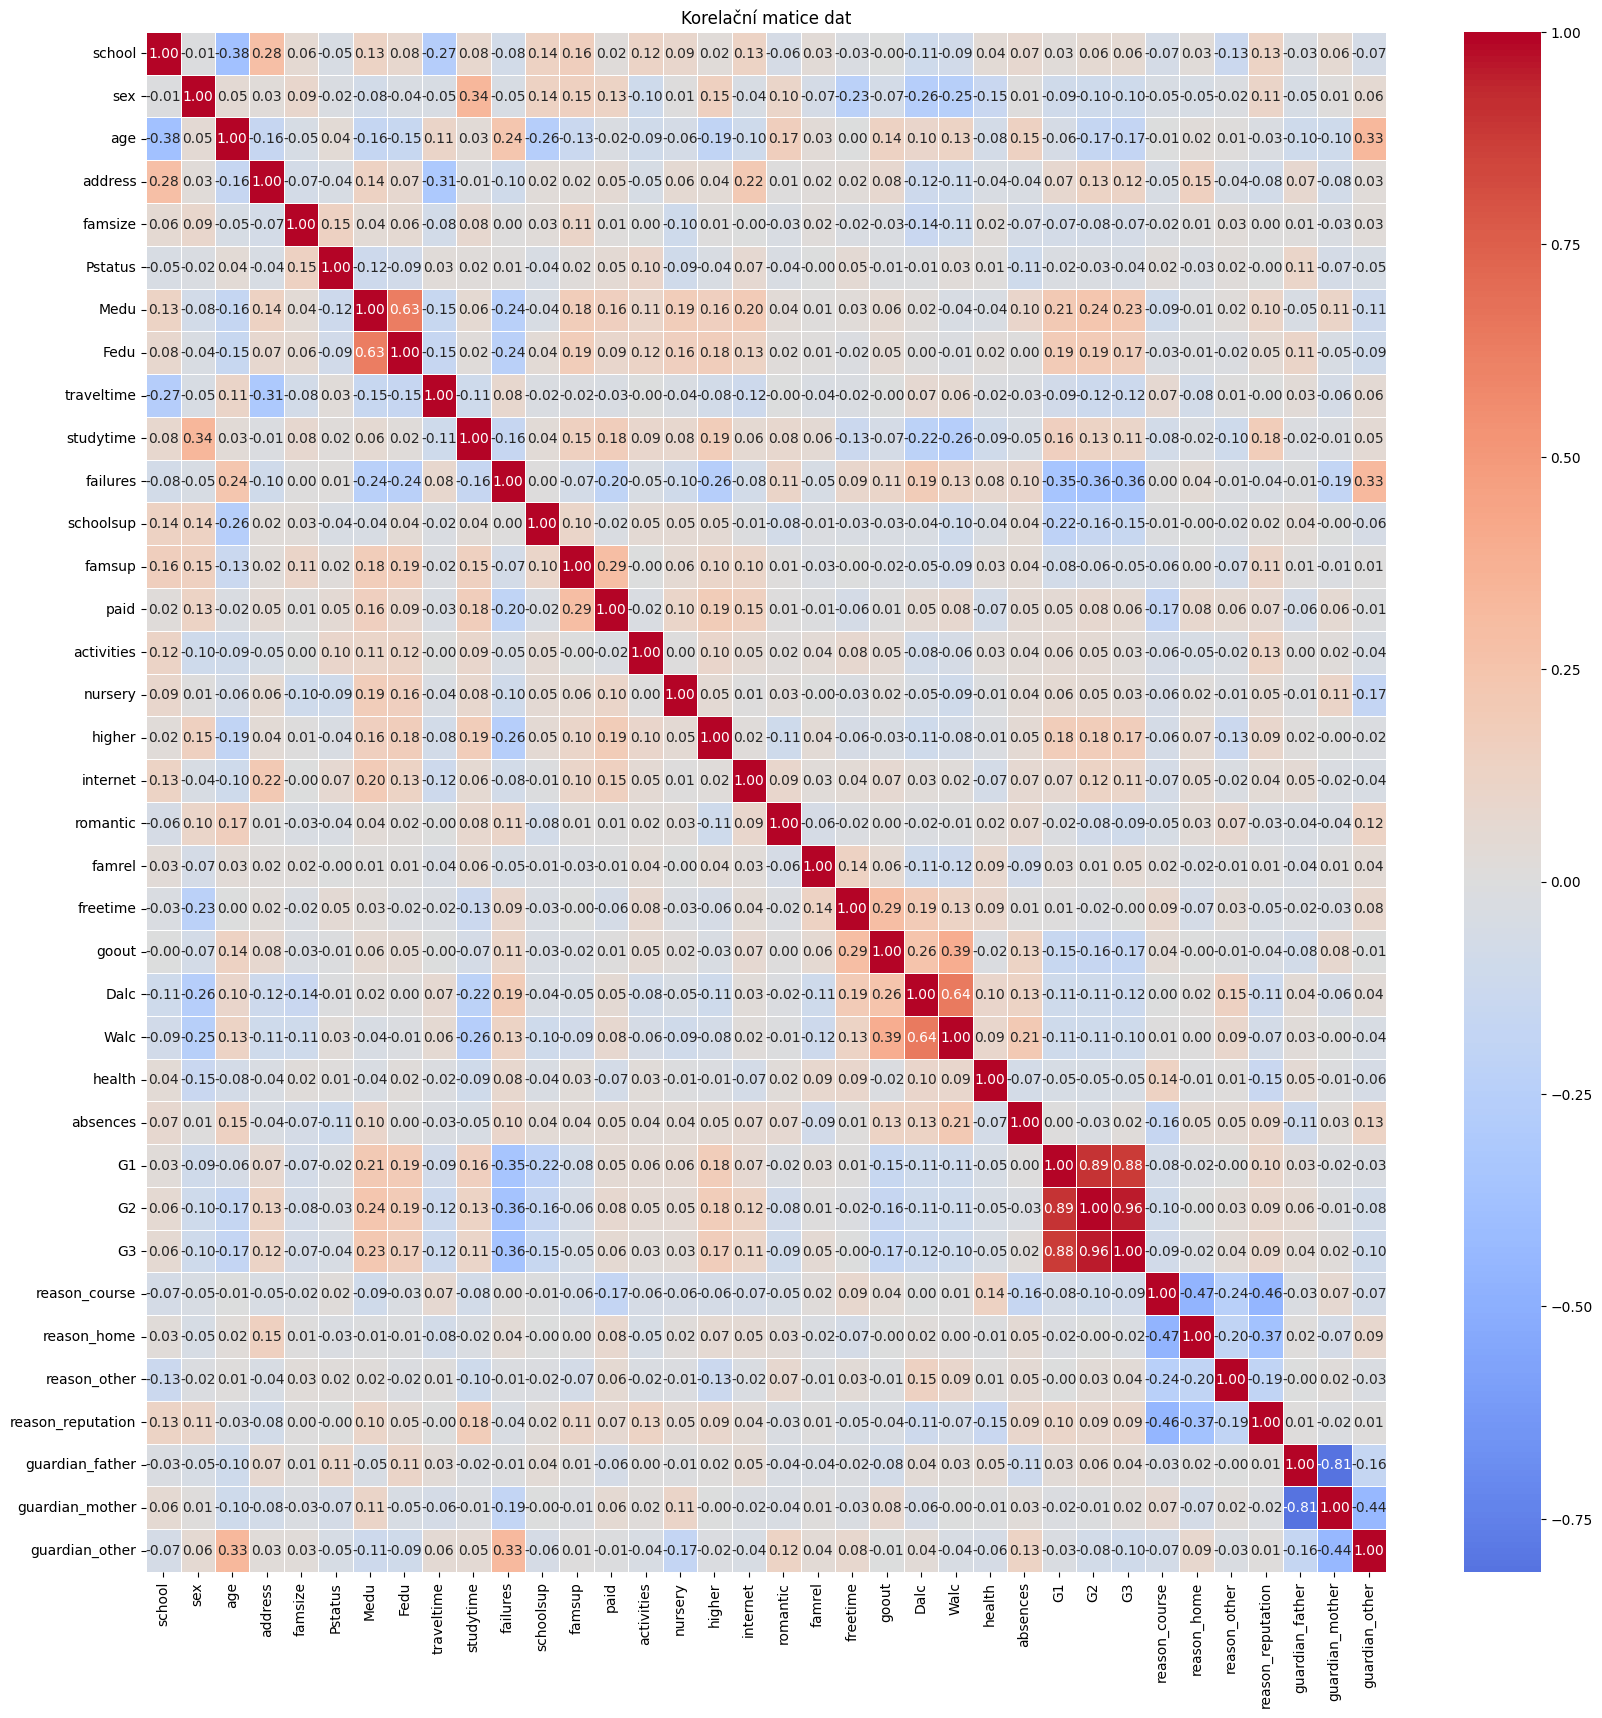

In [43]:
#cols to calc corr matrix on
all_cols = df_enc.columns
#calcs correlation matrix
corr_matrix = df_enc[all_cols].corr(method='spearman')
#graph plotting
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_matrix,
    annot=True, #incl r-value in graph
    fmt=".2f", #format r-value
    cmap='coolwarm', #color scale: cool=positive, warm=negative
    center=0, #center the color scale to 0 => white = 0
    linewidths=.5, #adds space between cells
)
plt.title('Korelační matice dat')
plt.show()

### Závěr
* Patrný nedostatek korelací
* S přibývajícím věkem rostě šance na opatrovníka jiného než rodiče
* Studenti, kteří častěji chodí ven, častěji požívají alkohol o víkendech
### Relativně silné korelace
* Známky G1-3
* Vzdělaní rodičů
* Popíjení alkoholu
* Negativní korelace u opatrovníka, buďto je jím otec nebo matka
### Další kroky
* zahodit G kromě G3
* zahodit Walc - Dalc je stabilnější
* zahodit Fedu - z předchozích korelací patrné, že Medu má větší vliv

In [44]:
#drop "correlated" cols
df_enc = df_enc.drop('G1', axis=1)
df_enc = df_enc.drop('G2', axis=1)
df_enc = df_enc.drop('Walc', axis=1)
df_enc = df_enc.drop('Fedu', axis=1)

In [45]:
pd.set_option('display.max_columns', None)
describe_df = df_enc.describe().transpose()
print(describe_df[describe_df['max'] > 1])

            count       mean       std   min   25%   50%   75%   max
age         395.0  16.696203  1.276043  15.0  16.0  17.0  18.0  22.0
Medu        395.0   2.749367  1.094735   0.0   2.0   3.0   4.0   4.0
traveltime  395.0   1.448101  0.697505   1.0   1.0   1.0   2.0   4.0
studytime   395.0   2.035443  0.839240   1.0   1.0   2.0   2.0   4.0
failures    395.0   0.334177  0.743651   0.0   0.0   0.0   0.0   3.0
famrel      395.0   3.944304  0.896659   1.0   4.0   4.0   5.0   5.0
freetime    395.0   3.235443  0.998862   1.0   3.0   3.0   4.0   5.0
goout       395.0   3.108861  1.113278   1.0   2.0   3.0   4.0   5.0
Dalc        395.0   1.481013  0.890741   1.0   1.0   1.0   2.0   5.0
health      395.0   3.554430  1.390303   1.0   3.0   4.0   5.0   5.0
absences    395.0   5.708861  8.003096   0.0   0.0   4.0   8.0  75.0
G3          395.0  10.415190  4.581443   0.0   8.0  11.0  14.0  20.0


In [46]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
#selecting cols for standard scaler
ss_cols = ['age', 'Medu', 'traveltime', 'studytime', 'famrel', 'freetime', 'goout', 'Dalc', 'health', 'G3'] 
#skewed cols for powertransforming
pt_cols = ['absences', 'failures']

#copying of selected cols 
df_ss = df_enc[ss_cols].copy()
df_pt = df_enc[pt_cols].copy()

#normalizers for pt_cols
pt = PowerTransformer(method='yeo-johnson')
ss = StandardScaler()

#powertransforming to limit skewedness
df_ptDone = pt.fit_transform(df_pt.values)
#then standard scaling to adjust distribution from -1 to 1
df_ptAndssDone = ss.fit_transform(df_ptDone)

#seperate standardscaler
ss_only = StandardScaler()
df_ssDone = ss_only.fit_transform(df_ss.values)

#overwriting data in original df_enc with normalized data
df_enc[ss_cols] = df_ssDone
df_enc[pt_cols] = df_ptAndssDone

## K-means clustering

In [47]:
#libs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import sklearn.preprocessing, sklearn.cluster, sklearn.metrics

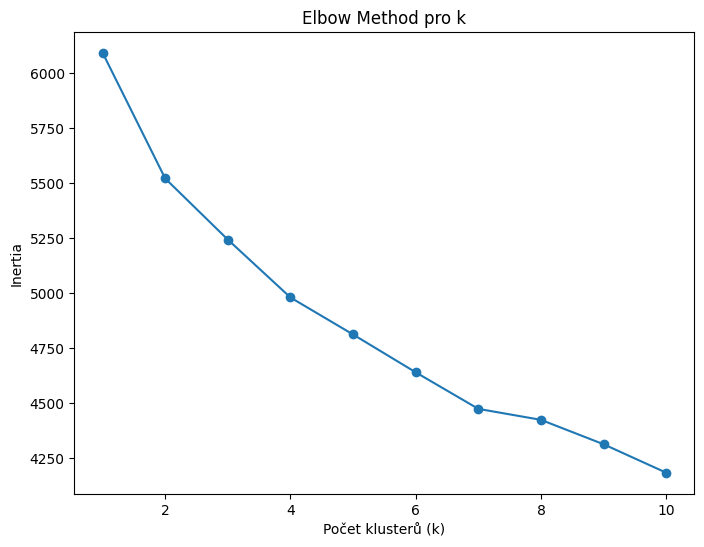

In [48]:
inertia = []  #stores inertia values for different 'k'
range_k = range(1, 11)  #trying 'k' from 1 to 10 clusters

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_enc)
    inertia.append(kmeans.inertia_)

#plotting the elbow method
plt.figure(figsize=(8, 6))
plt.plot(range_k, inertia, marker='o')
plt.title('Elbow Method pro k')
plt.xlabel('Počet klusterů (k)')
plt.ylabel('Inertia')
plt.show()
     

Vhodný počet clusterů pro kompaktnost (body blízko centroidu) je patrně 7.

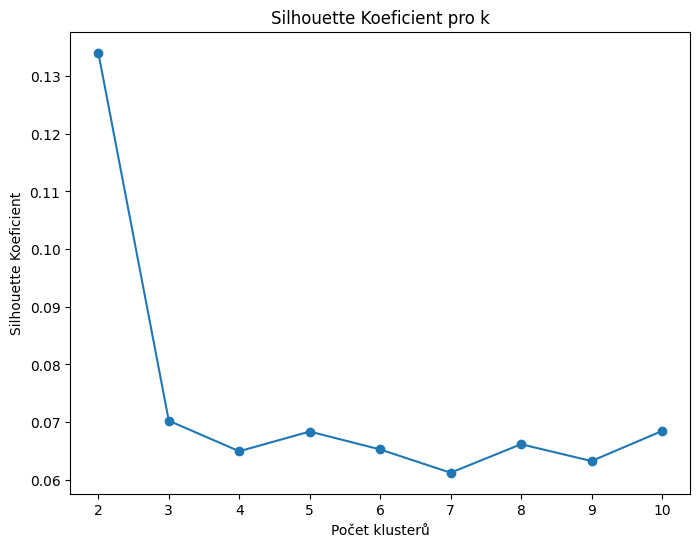

In [49]:
silhouette_scores = []

for k in range_k[1:]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_enc)
    score = silhouette_score(df_enc, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the Silhouette Coefficients
plt.figure(figsize=(8, 6))
plt.plot(range_k[1:], silhouette_scores, marker='o')
plt.title('Silhouette Koeficient pro k')
plt.xlabel('Počet klusterů')
plt.ylabel('Silhouette Koeficient')
plt.show()

Vhodný počet klusterů pro dobré oddělení je 2.

### Závěr - rozhodl jsem se pro 7 klusterů.

In [56]:

kmeans = KMeans(n_clusters=7, random_state=42)
kmeans.fit(df_enc)

df_enc['cluster'] = kmeans.labels_

In [55]:
cluster_cnt = df_enc['cluster'].value_counts()
cluster_cnt.sort_index()

cluster
0    78
1    52
2    30
3    83
4    40
5    65
6    47
Name: count, dtype: int64

In [59]:
df_enc.groupby('cluster').mean()

,school,sex,age,address,famsize,Pstatus,Medu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,health,absences,G3,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.987342,0.341772,-0.824397,0.886076,0.721519,0.886076,0.310277,-0.461541,-0.344328,-0.485033,0.202532,0.670886,0.417722,0.582278,0.822785,1.000000,0.873418,0.177215,0.344894,0.208095,-0.576063,-0.313036,0.585260,-0.465598,0.589805,0.367089,0.341772,0.063291,0.227848,0.303797,0.658228,0.037975
1,0.680851,0.489362,0.238380,0.617021,0.680851,0.936170,-0.996748,0.853336,-0.397667,-0.515691,0.063830,0.446809,0.382979,0.276596,0.723404,0.914894,0.680851,0.276596,-0.104118,-0.427961,-0.614577,-0.229782,-0.016215,-0.145641,0.137109,0.382979,0.276596,0.148936,0.191489,0.382979,0.574468,0.042553
2,0.833333,0.375000,-0.219342,0.708333,0.583333,0.791667,0.419780,0.194126,-0.290841,-0.307488,0.041667,0.625000,0.666667,0.500000,0.750000,1.000000,1.000000,0.333333,-1.612805,-0.444845,0.126939,0.911243,-0.969432,0.340440,0.555801,0.250000,0.250000,0.250000,0.250000,0.250000,0.750000,0.000000
3,0.943662,0.718310,0.028399,0.802817,0.746479,0.845070,0.435346,-0.238883,1.016349,-0.412278,0.084507,0.718310,0.619718,0.464789,0.901408,1.000000,0.873239,0.323944,0.140833,-0.645445,-0.427261,-0.398209,-0.531153,0.036441,0.426390,0.281690,0.197183,0.056338,0.464789,0.126761,0.845070,0.028169
4,0.900000,0.600000,0.257996,0.700000,0.800000,0.950000,-0.456732,0.289826,-0.072112,0.840751,0.050000,0.600000,0.200000,0.550000,0.725000,0.825000,0.775000,0.550000,-0.105306,-0.110709,0.149424,-0.147269,0.086832,-1.286201,-2.210661,0.500000,0.300000,0.025000,0.175000,0.200000,0.675000,0.125000
5,0.826087,0.391304,0.716003,0.753623,0.652174,0.898551,-0.208193,0.251338,-0.370811,1.401079,0.130435,0.507246,0.434783,0.478261,0.724638,0.884058,0.811594,0.449275,0.143112,0.490373,0.462580,0.925498,0.268703,0.749876,-0.141417,0.391304,0.289855,0.115942,0.202899,0.173913,0.550725,0.275362
6,0.907692,0.723077,-0.039272,0.830769,0.738462,0.938462,0.215163,-0.311980,0.141263,-0.478430,0.215385,0.661538,0.492308,0.646154,0.830769,0.984615,0.846154,0.323077,0.010656,0.473387,0.981357,-0.246707,-0.100138,0.501171,0.023579,0.384615,0.261538,0.076923,0.276923,0.200000,0.784615,0.015385



### 0. skupina
* spíše mladší muži
* silné rodinné zázemí
* vzdělaní rodiče
* bydliště blízko školy
* mají více volného času ale nechodí moc ven, nepožívají tolik alkohol
* jsou zdraví
* nízké absence, nízké selhání
* nejlepší známky
* chtějí pokračovat ve studiu
* většina z GP
### 1.skupina
* spíše ženy
* vyšší absence a vyšší selhání kurzu, relativně nízké známky
* relativně starší
* nejvyšší pravděpodobnost že opatrovník bude někdo jiný než rodič
* studují kvůli kurzu nebo na pohnutku z domova
* rodiče postrádají vyšší vzdělání
* menší vztah s rodinou
* průměrný společenský život
### 2.skupina
* spíše mladší muži
* bydlí dále od školy
* velká konzumace alkoholu
* tráví hodně času venku
* vyšší absence, méně času na studium, ale i přesto mají relativně dobré výsldky
* průměrné zdraví
* s rodinou si tolik nerozumí, ale jsou jí podporovány
### 3.skupina
* spíše ženy, průměrný věk
* bydlí spíš mimo město ale stále relativně blízko školy
* převážně z GP
* silné rodinné zázemí a podpora, ačkoliv svůj vztah s rodinnou nehodnotí jako moc dobrý
* nízká konzumace alkoholu, horší zdraví a nízký společenský život
* dobré studijní výsledky, chtějí studovat dálě
### 4.skupina
* mix pohlaví, spíše ženy, průměrný až starší věk
* větší rodinny, rodiče jsou spolu a podporují své potomky
* rodiče postrádají vzdělání
* velký počet absencí, špatně známky a nesplňené kurzy navzdory velkému zájmu o kurz
* nejvyšší počet partnerů/partnerek
* nízká podpora školy, placených doučování a nejmenší přístup k internetu => chudší rodinny?
* nejnižší zájem o vyšši vzdělání
### 5.skupina
* spiš muži, průměrný věk
* spíše z města s nízkým časem tranzitu
* nejlepší vztah s rodinnou, opatrovník většinou matka (největší skóre)
* nejvíce volného času, spíše nižší konzumace alkoholu a nejvyšší absence, průměrné známky
### 6.skupina
* nejvíce studentů z MS, stále ovšem převážne z GP
* spíše ženy průměrného až staršího věku
* nejhorší vzdělání rodičů
* hodně dojíždění
* slabý společenský život a nízká konzumace alkoholu
* průměrné výsledky

## Závěry
* klustery jsou poměrně vyrovnané
* důvod pro účast na kurzu má patrně velmi nízký vliv na výsledky
* škola MS je patrně mimo město
* zájem o vyšší studium koreluje s lepšímy výsledky
* ženy konzumují méně alkoholu než muži
* muži mají lepší výsledky
* ženy mají více partnerů
* studenti z města mají lepší výsledky a více společenského života
* většina studentů nepovažuje svůj vztah z rodinnou jako příliš dobrý, nicméně to nemá přílišný vliv na podporu od ní ani studijní výsledky

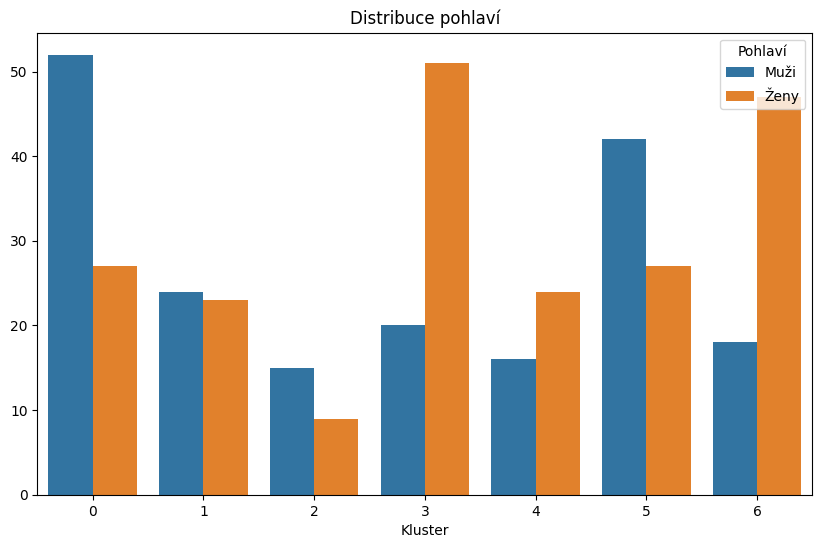

In [68]:
plt.figure(figsize=(10, 6))
sns.countplot(x='cluster', hue='sex', data=df_enc)
plt.title('Distribuce pohlaví')
plt.xlabel('Kluster')
plt.ylabel('')

handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['Muži', 'Ženy']
if len(labels) == len(new_labels):
    plt.legend(handles=handles, labels=new_labels, title='Pohlaví')

plt.show()

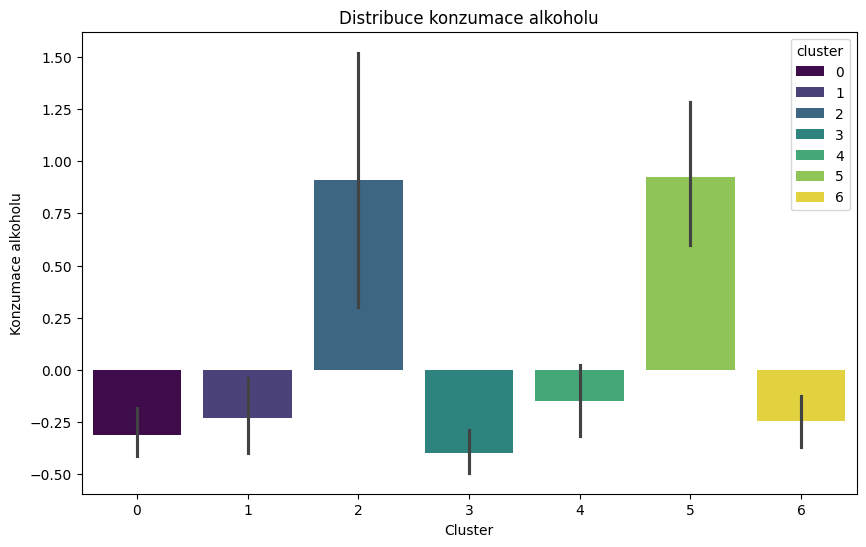

In [69]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cluster', y='Dalc', data=df_enc, hue='cluster', palette='viridis')
plt.title('Distribuce konzumace alkoholu')
plt.xlabel('Cluster')
plt.ylabel('Konzumace alkoholu')
plt.show()

Muži patrně požívají více alkoholu.

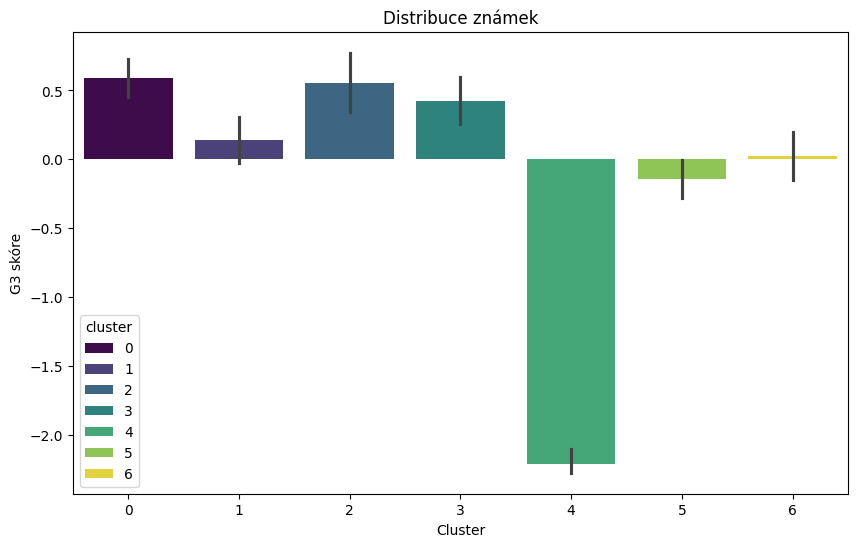

In [78]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cluster', y='G3', data=df_enc, hue='cluster', palette='viridis')
plt.title('Distribuce známek')
plt.xlabel('Cluster')
plt.ylabel('G3 skóre')
plt.show()

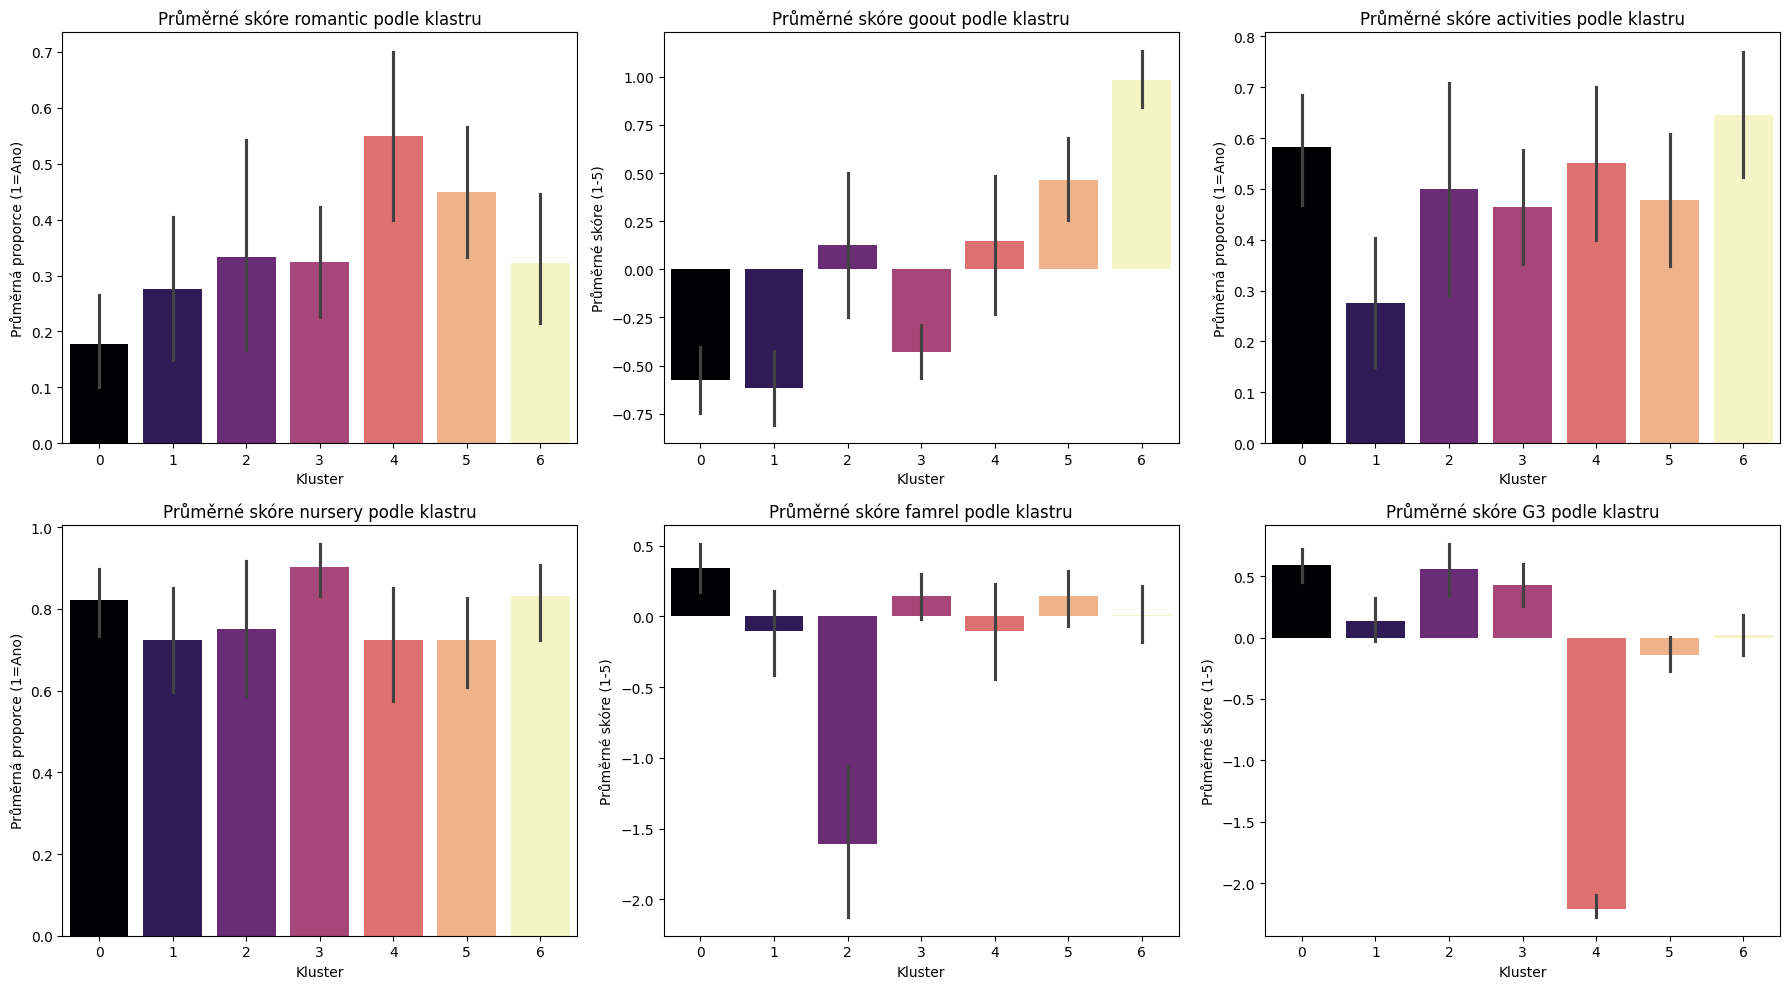

In [77]:
variables = ['romantic', 'goout', 'activities', 'nursery', 'famrel', 'G3']

#subplots prep
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() 

#barplot generation
for i, var in enumerate(variables):
    sns.barplot(
        x='cluster', 
        y=var, 
        data=df_enc, 
        ax=axes[i], 
        hue='cluster', 
        legend=False,
        palette='magma',
    )
    axes[i].set_title(f'Průměrné skóre {variables[i]} podle klastru')
    axes[i].set_xlabel('Kluster')
    
    #settings lbls
    if var in ['romantic', 'activities', 'nursery']:
        axes[i].set_ylabel('Průměrná proporce (1=Ano)')
    else:
        axes[i].set_ylabel(f'Průměrné skóre (1-5)')


plt.tight_layout() #layout optimalization
plt.show()

Žádný patrný vztah ukazetelů společenského života a studijních výsledků, možná kromě partnera.

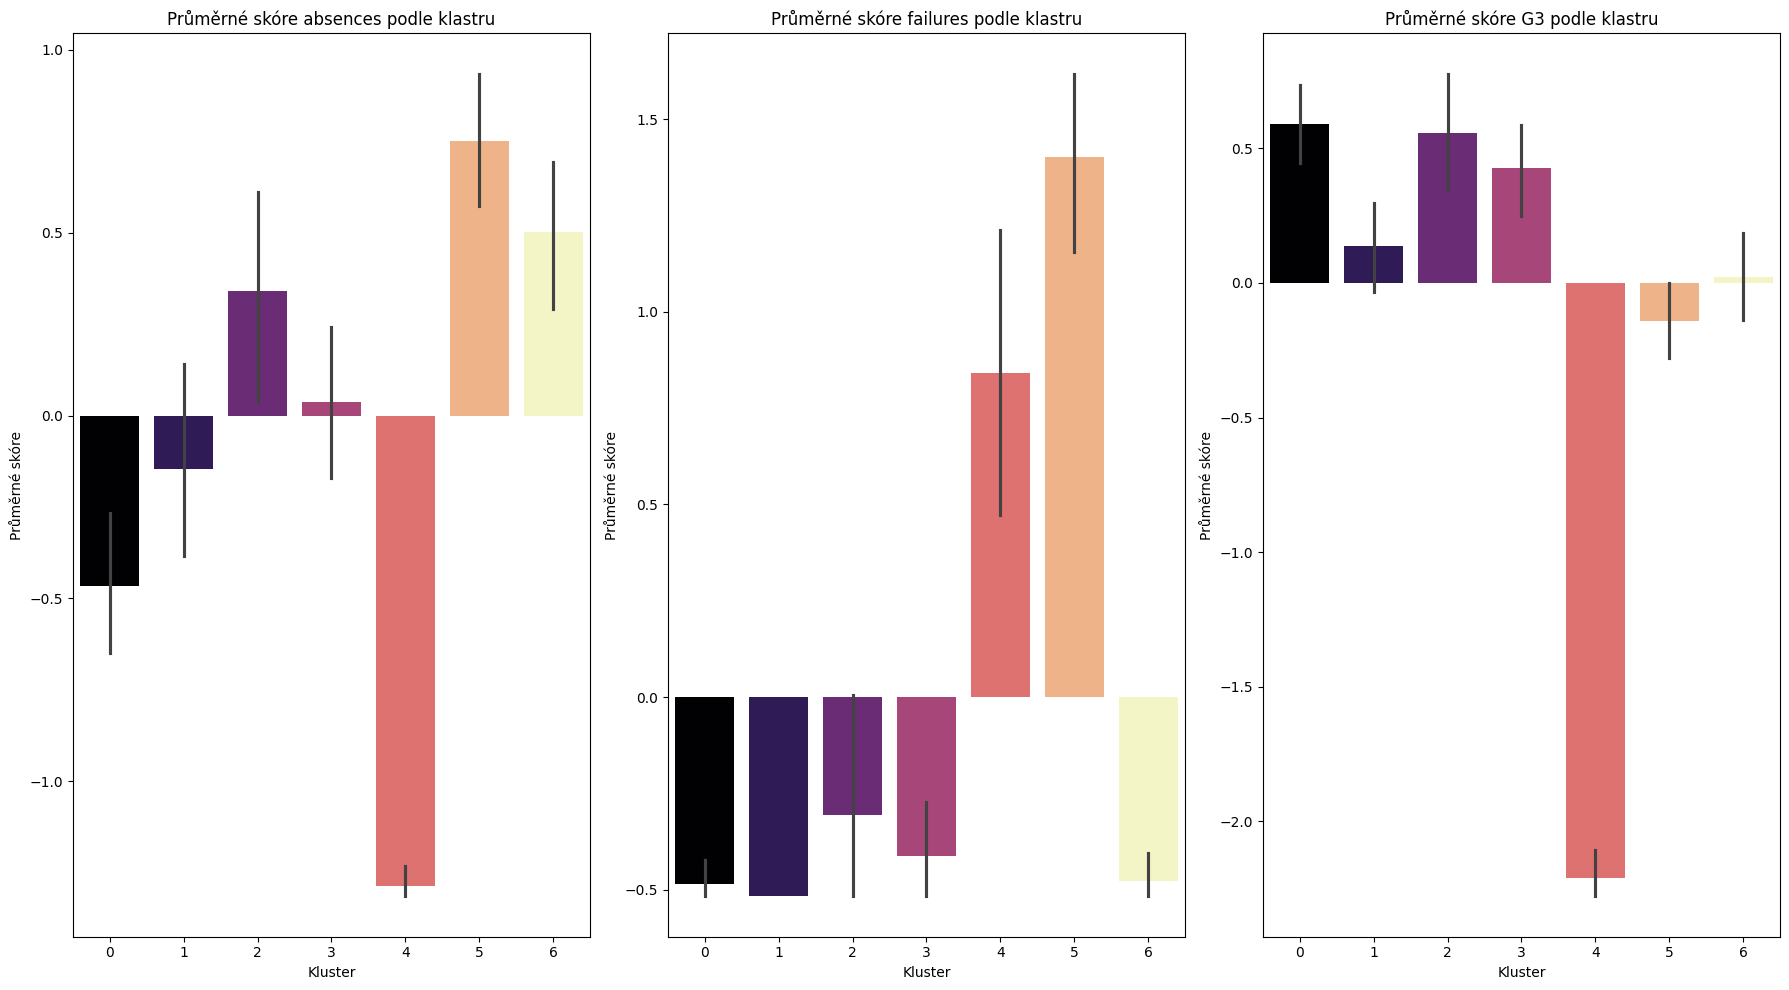

In [79]:
variables = ['absences', 'failures', 'G3']

#subplots prep
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 10))
axes = axes.flatten() 

#barplot generation
for i, var in enumerate(variables):
    sns.barplot(
        x='cluster', 
        y=var, 
        data=df_enc, 
        ax=axes[i], 
        hue='cluster', 
        legend=False,
        palette='magma',
    )
    axes[i].set_title(f'Průměrné skóre {variables[i]} podle klastru')
    axes[i].set_xlabel('Kluster')
    
    #settings lbls
    axes[i].set_ylabel(f'Průměrné skóre')


plt.tight_layout() #layout optimalization
plt.show()

Příliš vysoké absence mají patrně negativní vliv na finální známku. Na druhou stranu kluster 1 má druhé největší absence, ale zároveň nejlepší známky.

## Complete linkage method, agglomerative clustering

## Complete linkage
* Vzdálenost klusterů podle dvou nejvzdálenějších bodů
* Kompaktní klustery
* Citlivé na outliery

In [151]:
#df_enc = df_enc.drop('cluster', axis=1) #clear data

In [85]:
#req libs
from scipy.cluster.hierarchy import dendrogram, linkage

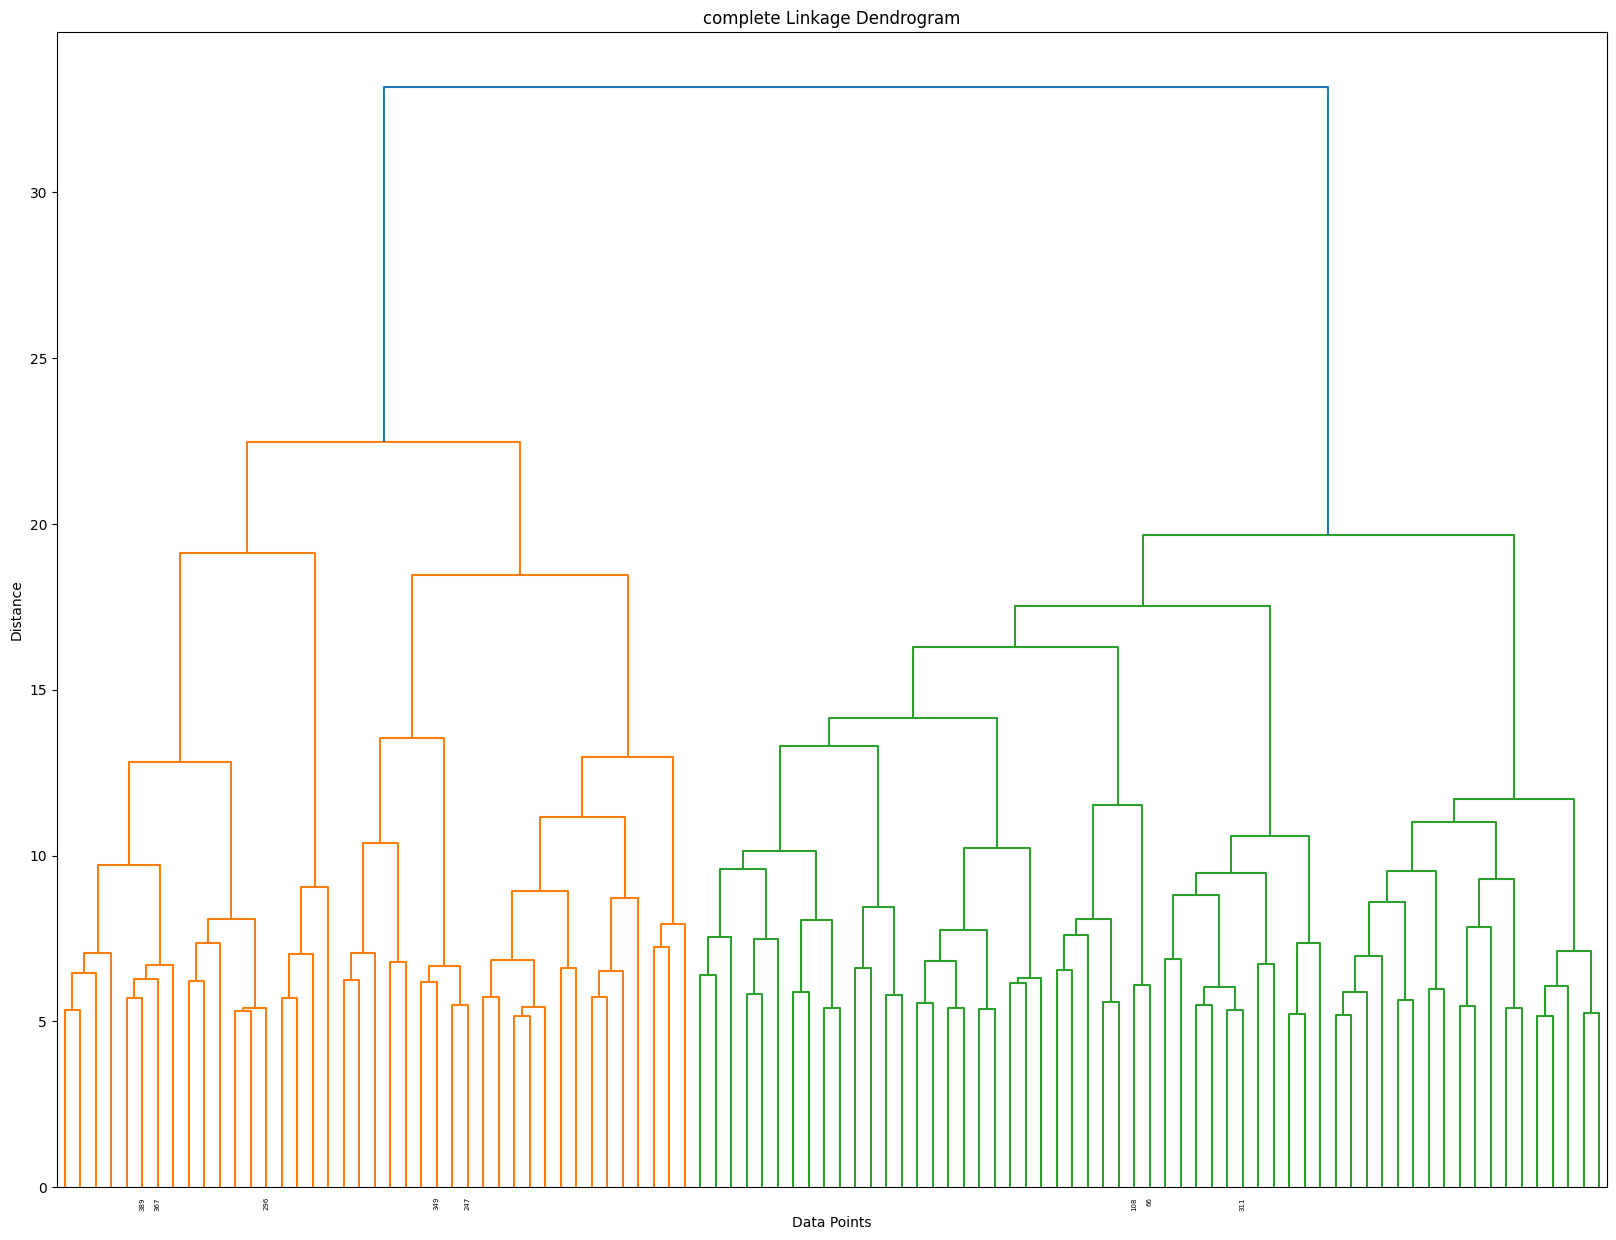

In [120]:
linked_single = linkage(df_enc, method='ward')
plt.figure(figsize=(20, 15))
dendrogram(linked_single,
    truncate_mode='lastp',
    p=100,
    distance_sort='descending',
    show_leaf_counts=False)
plt.title('complete Linkage Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

Na základě dendogramu jsem se rozhodl pro distance 20.

In [142]:
from sklearn.cluster import AgglomerativeClustering

agglomerative_clustering = AgglomerativeClustering(distance_threshold=20, n_clusters = None, linkage='ward')
df_enc['cluster'] = agglomerative_clustering.fit_predict(df_enc)

cluster_counts = df_enc['cluster'].value_counts()
cluster_counts

cluster
0    230
1     80
2     48
3     37
Name: count, dtype: int64

Vyšli mi 4 klustery.

In [149]:
df_enc.groupby('cluster').mean()

,school,sex,age,address,famsize,Pstatus,Medu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,health,absences,G3,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.917391,0.513043,-0.218774,0.813043,0.734783,0.904348,0.030403,-0.143945,0.154829,-0.505161,0.126087,0.630435,0.486957,0.521739,0.826087,0.978261,0.830435,0.278261,0.198136,-0.009379,-0.226951,-0.276783,0.148673,-0.066671,0.347308,0.386957,0.234783,0.095652,0.282609,0.260870,0.713043,0.026087
1,0.900000,0.600000,0.346271,0.687500,0.712500,0.937500,-0.559627,0.235994,-0.116852,1.386647,0.137500,0.575000,0.250000,0.537500,0.687500,0.825000,0.800000,0.475000,-0.063431,-0.135769,0.037000,-0.203473,0.113839,-0.324279,-1.117918,0.425000,0.275000,0.062500,0.237500,0.162500,0.612500,0.225000
2,0.833333,0.666667,-0.006829,0.791667,0.708333,0.791667,0.838982,0.044594,-0.091997,-0.465233,0.145833,0.687500,0.604167,0.520833,0.854167,1.000000,0.895833,0.354167,-0.821833,-0.215127,0.482946,-0.072330,-1.059454,0.289973,0.314486,0.145833,0.437500,0.062500,0.354167,0.145833,0.812500,0.041667
3,0.702703,0.270270,0.620110,0.729730,0.567568,0.891892,-0.067400,0.326683,-0.590451,0.745578,0.108108,0.486486,0.540541,0.351351,0.756757,0.972973,0.837838,0.351351,-0.028346,0.630938,0.704248,2.254321,0.204104,0.739405,-0.149806,0.405405,0.324324,0.162162,0.108108,0.270270,0.567568,0.162162


### 0. skupina
* mix pohlaví, spíše mladší
* spíše žijí ve městě, nejkratší dojíždění
* nejméně romantických partnerů
* relativně nízké vzdělání rodičů
* nejlepší známky i přes vyšší absenci
* nejlepší vztahy s rodinou, jinak je jejich společenský život méně intenzivní, požívají nejméně alkoholu
* nejvíce času věnovanému studiu
### 1. skupina
* spíš ženy, starší věk
* největší část, která bydlí na venkově, urbanisté stále převládají
* rodiče nedosahují tak vysokého vzdělaní
* vysoké absence, selhání a nízké známy
* nejmenší přístup k internetu
* největší počet romantický partnerů
### 2. skupina
* mladší ženy
* hodnotí nejhorší rodinné vztahy, ale často chodí ven a mají průměrné množství aktivit
* rodiče ale dosáhli vysoké úrovně vzdělání a podporují je ve studiju
* největší chuť pokračovat ve vyšším studiu
* nejnižší absence, dobré známky
* nejhorší zdraví
### 3. skupina
* primárně starší muži
* hodně volného času, chodí často ven, požívají hodně alkoholu, nejvyšší absence, což se odráží na známkách, ne ale tak hodně jako ve skupině 2
* průměrné zdraví

### Závěr
* méně klusterů než v k-means klusteringu. Dle mého názoru nepřibyli žádné nové objevi.
* kluster 0 je zdaleka největší a distrubuce pohlaví je nejvyrovnanějšší (viz. níže), zároveň v něm studenti mají nejlepší známky
* klustery 1 a 3 lze označit za problémové skupiny kvůli vysokým absencím, horším známkám a tendencemi k alkoholismu mezi muži. Také se jedná o starší studenty.
* kluster 2 tvoří z větší části studenti s nízkou absencí (navzdory horšímu zdraví), jež hodnotí své rodinné vztahy jako nejhorší. Jako důvod ke studiu se nejčastěji objevuje tlak z domova (rodiče sami dosáhli relatvině vysoké úrovně) a reputace, oproti dalším klusterům kde dominuje atraktivita kurzu.

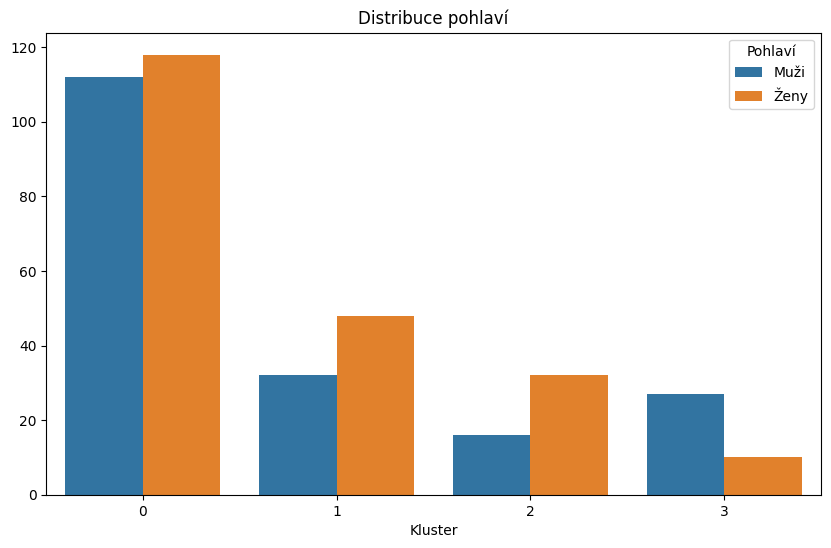

In [152]:
plt.figure(figsize=(10, 6))
sns.countplot(x='cluster', hue='sex', data=df_enc)
plt.title('Distribuce pohlaví')
plt.xlabel('Kluster')
plt.ylabel('')

handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['Muži', 'Ženy']
if len(labels) == len(new_labels):
    plt.legend(handles=handles, labels=new_labels, title='Pohlaví')

plt.show()

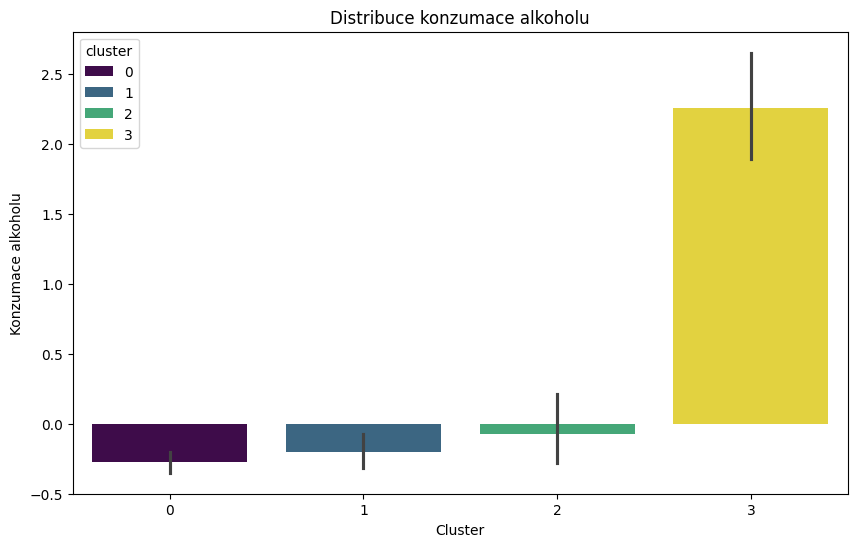

In [153]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cluster', y='Dalc', data=df_enc, hue='cluster', palette='viridis')
plt.title('Distribuce konzumace alkoholu')
plt.xlabel('Cluster')
plt.ylabel('Konzumace alkoholu')
plt.show()

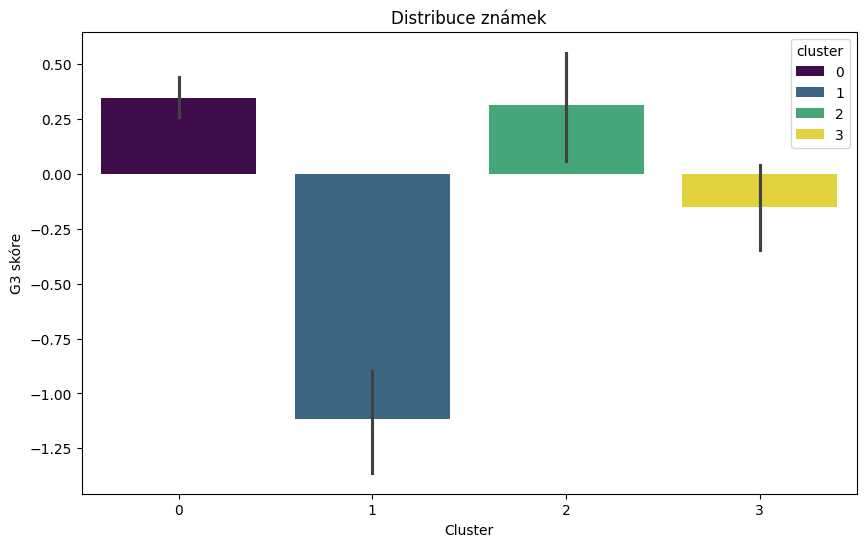

In [154]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cluster', y='G3', data=df_enc, hue='cluster', palette='viridis')
plt.title('Distribuce známek')
plt.xlabel('Cluster')
plt.ylabel('G3 skóre')
plt.show()

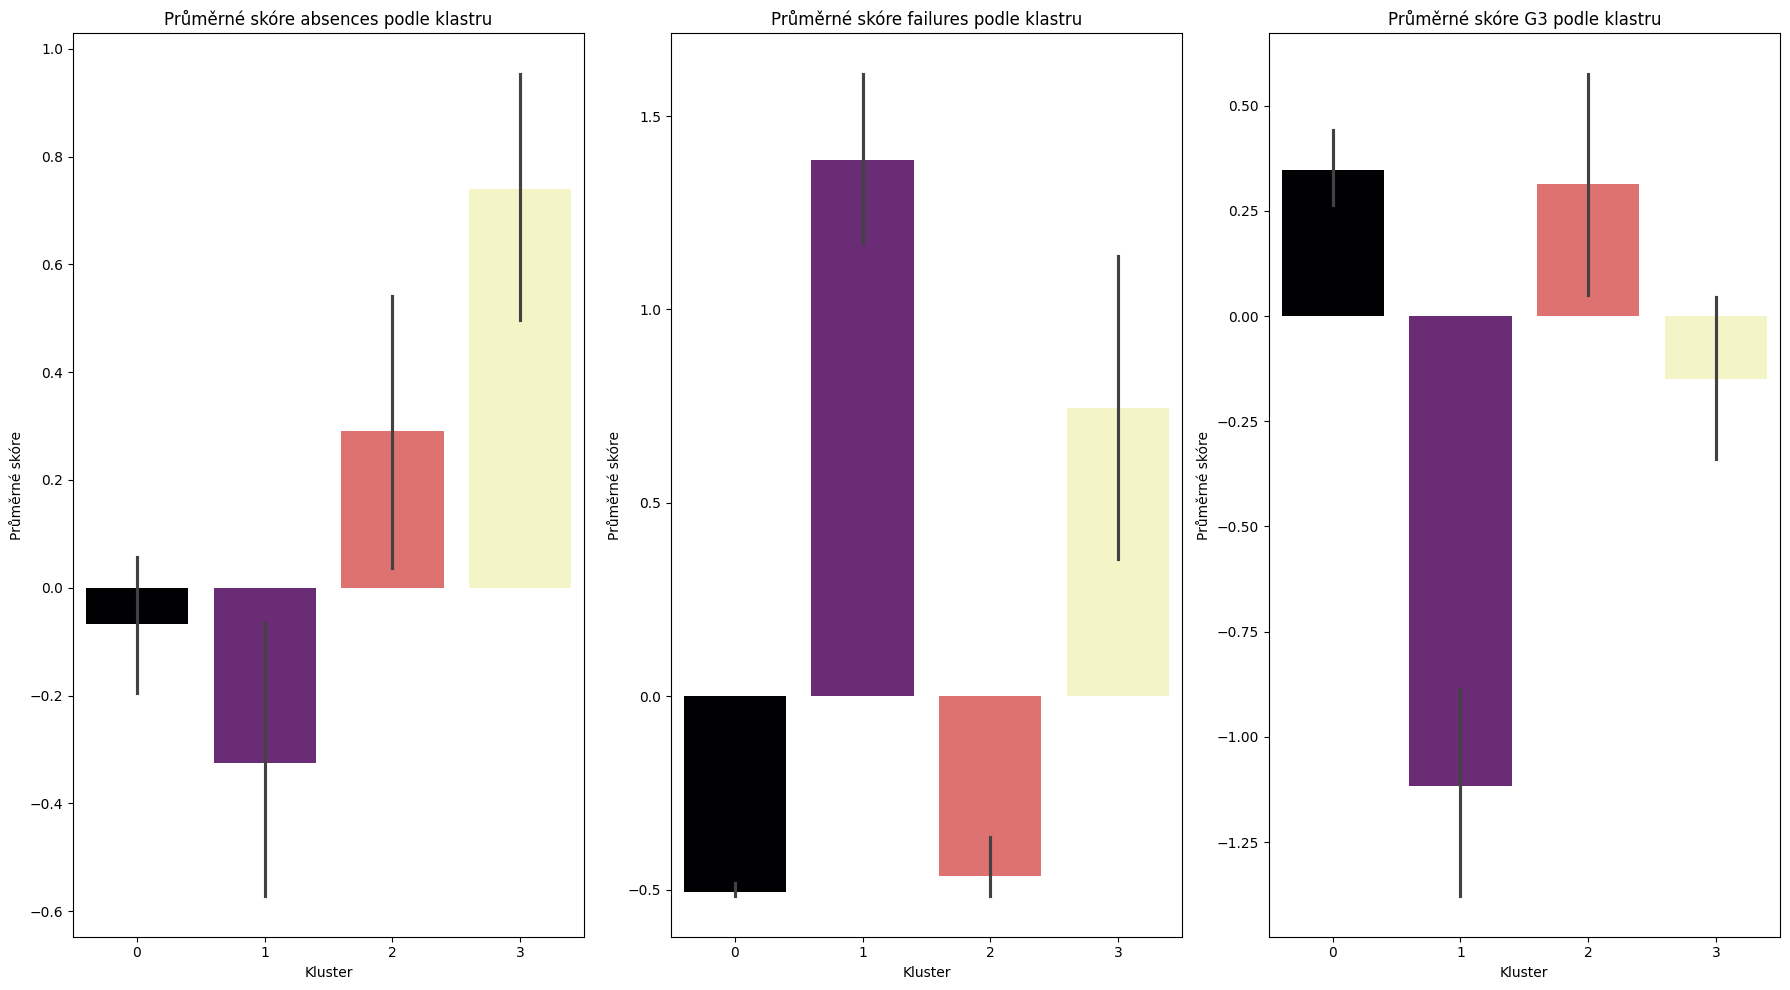

In [155]:
variables = ['absences', 'failures', 'G3']

#subplots prep
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 10))
axes = axes.flatten() 

#barplot generation
for i, var in enumerate(variables):
    sns.barplot(
        x='cluster', 
        y=var, 
        data=df_enc, 
        ax=axes[i], 
        hue='cluster', 
        legend=False,
        palette='magma',
    )
    axes[i].set_title(f'Průměrné skóre {variables[i]} podle klastru')
    axes[i].set_xlabel('Kluster')
    
    #settings lbls
    axes[i].set_ylabel(f'Průměrné skóre')


plt.tight_layout() #layout optimalization
plt.show()

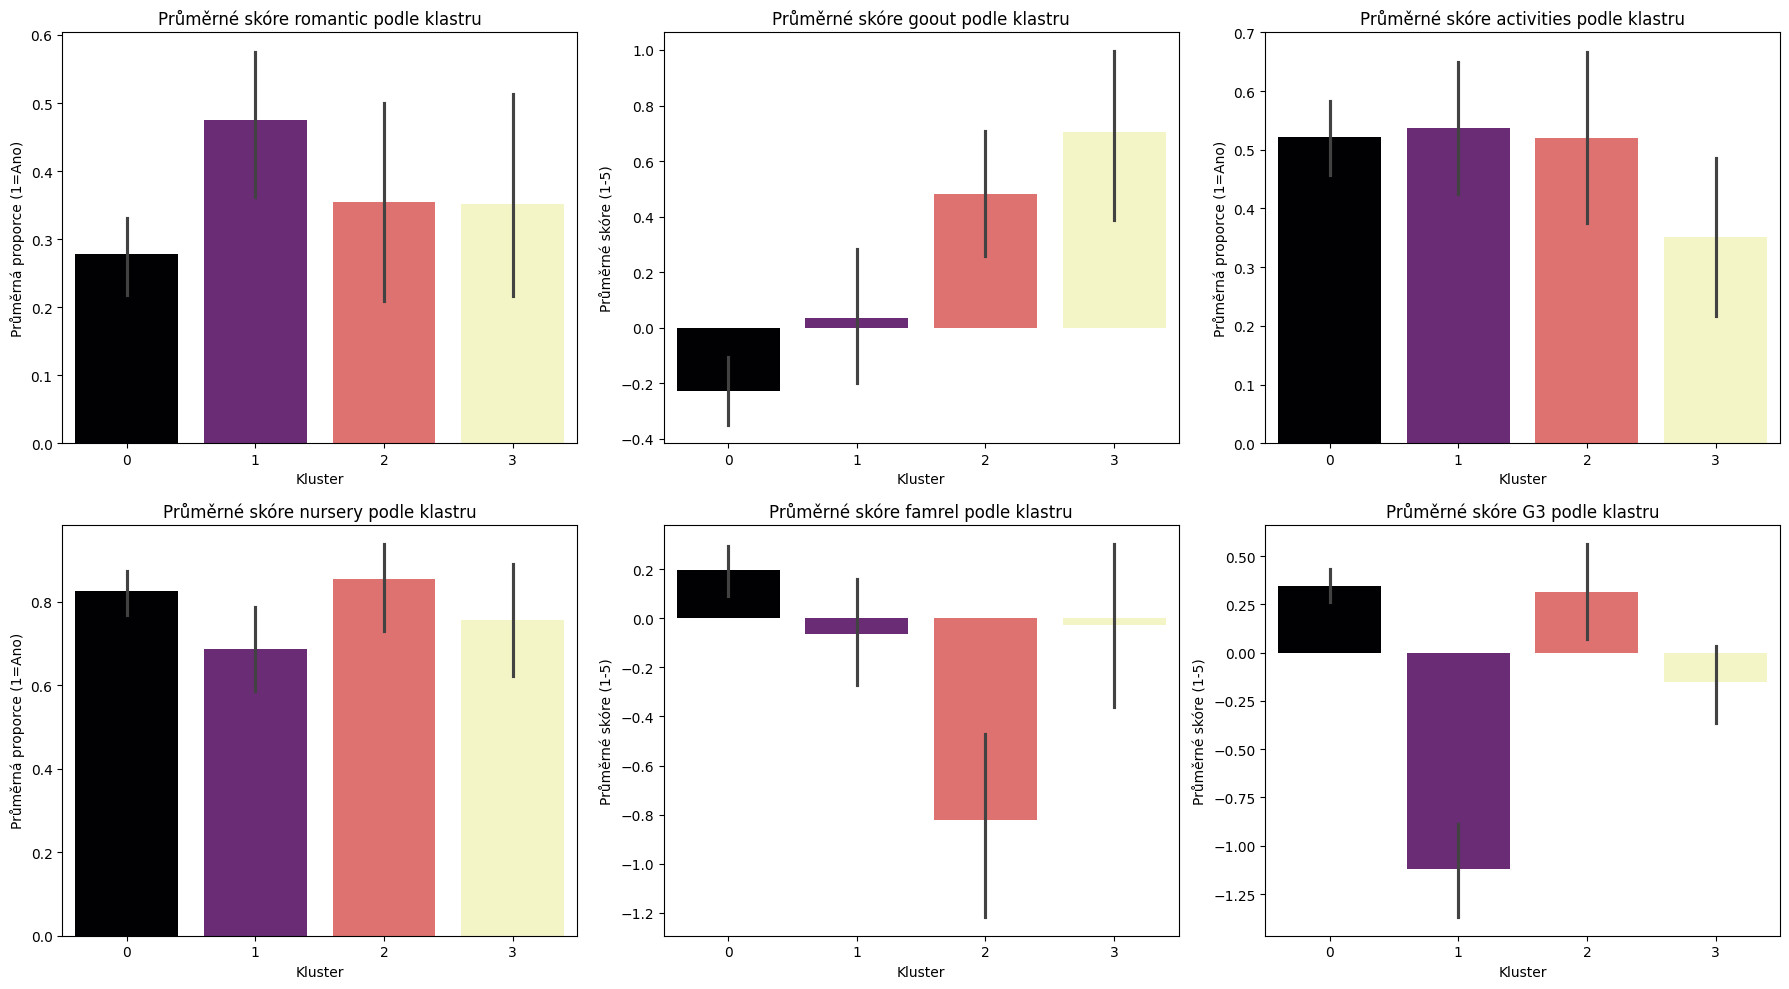

In [156]:
variables = ['romantic', 'goout', 'activities', 'nursery', 'famrel', 'G3']

#subplots prep
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() 

#barplot generation
for i, var in enumerate(variables):
    sns.barplot(
        x='cluster', 
        y=var, 
        data=df_enc, 
        ax=axes[i], 
        hue='cluster', 
        legend=False,
        palette='magma',
    )
    axes[i].set_title(f'Průměrné skóre {variables[i]} podle klastru')
    axes[i].set_xlabel('Kluster')
    
    #settings lbls
    if var in ['romantic', 'activities', 'nursery']:
        axes[i].set_ylabel('Průměrná proporce (1=Ano)')
    else:
        axes[i].set_ylabel(f'Průměrné skóre (1-5)')


plt.tight_layout() #layout optimalization
plt.show()

# Závěry na závěr
* Z dat relativně jasně vyplývá, že muži studující matematiku požívají více alkoholu a zároveň mají méně romantických partnerů než ženy
* Muži mají lepší známky, ženám to kazí kluster starších studentek, jejichž primární identifikátory je větší množství partnerů a že je jich větší část z venkova a mají horší vztah s rodinou.
* Matky dominují jako opatrovníci.
* Vyšší vzdělaní rodičů koreluje s vyšším úspěchem studentů (ať už chcou sami nebo je to od nich očekáváno z domova)
* Zájem o vyšší vzdělaní koreluje s lepšími známkami
* Internet je rozšířen i pro klustery, kde je větsí část studentů z venkova. V retrospketivě jsem ho patně mohl zahodit
* Studenti celkově považují svůj vztah s rodinnou za horší, nicméně to nemá moc vliv na jejich studijní výsledky
* Intenzita společenského života také nemá značný vliv na finální známku (alespoň já jsem žádný nenašel)
* Předchozí neúspěch v předmětu koreluje s nízkými známkami
* Požívání alkoholu v rozumné míře a absence v určitých mezích nemají silně negativní vliv na finální známku